In [1]:
pip install tensorflow jupyter pandas numpy matplotlib seaborn scikit-learn plotly yfinance ta sqlalchemy

  Obtaining dependency information for tensorflow from https://files.pythonhosted.org/packages/8f/a2/6d7e6a738e302530586d484895de2cf3fc158ad9c73b4504a670b2956dd9/tensorflow-2.21.0-cp311-cp311-win_amd64.whl.metadata
  Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl.metadata (4.5 kB)
  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/44/a0/97a6339859d4acb2536efb24feb6708e82f7d33b2ed7e036f2983fcced82/pandas-3.0.2-cp311-cp311-win_amd64.whl.metadata
  Using cached pandas-3.0.2-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/7e/0d/271aace3342157c64700c9ff4c59c7b392f3dbab393692e8db6fbe7ab96c/matplotlib-3.10.9-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: C:\Users\RAHUL\chidori_env\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

# Load your TCS data
df = pd.read_csv("TCS_stock_data.csv")  # change filename if different

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (1234, 10)

Columns: ['date', 'close', 'high', 'low', 'open', 'volume', 'ticker', 'daily_return', 'price_range', 'avg_price']

First 5 rows:
         date        close         high          low         open   volume  \
0  2021-04-15  2829.704102  2845.791249  2714.105507  2778.146335  6062760   
1  2021-04-16  2808.783203  2854.363438  2797.750957  2838.540050  3224657   
2  2021-04-19  2779.465820  2803.376673  2755.994506  2785.795132  2679106   
3  2021-04-20  2764.301270  2835.330725  2748.302113  2835.022962  3141893   
4  2021-04-22  2741.665039  2767.334041  2729.753504  2767.334041  1988980   

   ticker  daily_return  price_range    avg_price  
0  TCS.NS      3.701595   131.685742  2779.948378  
1  TCS.NS     -0.739332    56.612481  2826.057197  
2  TCS.NS     -1.043775    47.382166  2779.685590  
3  TCS.NS     -0.545592    87.028612  2791.816419  
4  TCS.NS     -0.818877    37.580537  2748.543773  

Data Types:
date                str
close           float64
high      

In [3]:
import os

# Create all folders
folders = ["src", "models", "data", "notebooks"]
for f in folders:
    os.makedirs(f, exist_ok=True)
    print(f"✅ Created: {f}/")

print("\n📁 Project structure ready!")

✅ Created: src/
✅ Created: models/
✅ Created: data/
✅ Created: notebooks/

📁 Project structure ready!


In [4]:
import shutil
import os

# Change this to your actual filename
your_file = "TCS_stock_data.csv"

if os.path.exists(your_file):
    shutil.copy(your_file, f"data/{your_file}")
    print(f"✅ Moved to data/{your_file}")
else:
    print("❌ File not found — check the filename!")

✅ Moved to data/TCS_stock_data.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load your data
df = pd.read_csv("data/TCS_stock_data.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print("✅ Data loaded!")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Latest Close: ₹{df['close'].iloc[-1]:.2f}")

✅ Data loaded!
Date range: 2021-04-15 → 2026-04-10
Latest Close: ₹2524.30


In [6]:
print("="*45)
print("        📋 TCS STOCK SUMMARY")
print("="*45)
print(f"  Total Trading Days : {len(df)}")
print(f"  Latest Close Price : ₹{df['close'].iloc[-1]:.2f}")
print(f"  All-Time High      : ₹{df['high'].max():.2f}")
print(f"  All-Time Low       : ₹{df['low'].min():.2f}")
print(f"  Avg Daily Volume   : {df['volume'].mean():,.0f}")
print(f"  Avg Daily Return   : {df['daily_return'].mean():.3f}%")
print(f"  Best Day Ever      : +{df['daily_return'].max():.2f}%")
print(f"  Worst Day Ever     : {df['daily_return'].min():.2f}%")
print(f"  Missing Values     : {df.isnull().sum().sum()}")
print("="*45)

        📋 TCS STOCK SUMMARY
  Total Trading Days : 1234
  Latest Close Price : ₹2524.30
  All-Time High      : ₹4348.04
  All-Time Low       : ₹2346.20
  Avg Daily Volume   : 2,439,097
  Avg Daily Return   : 0.002%
  Best Day Ever      : +6.63%
  Worst Day Ever     : -7.01%
  Missing Values     : 0


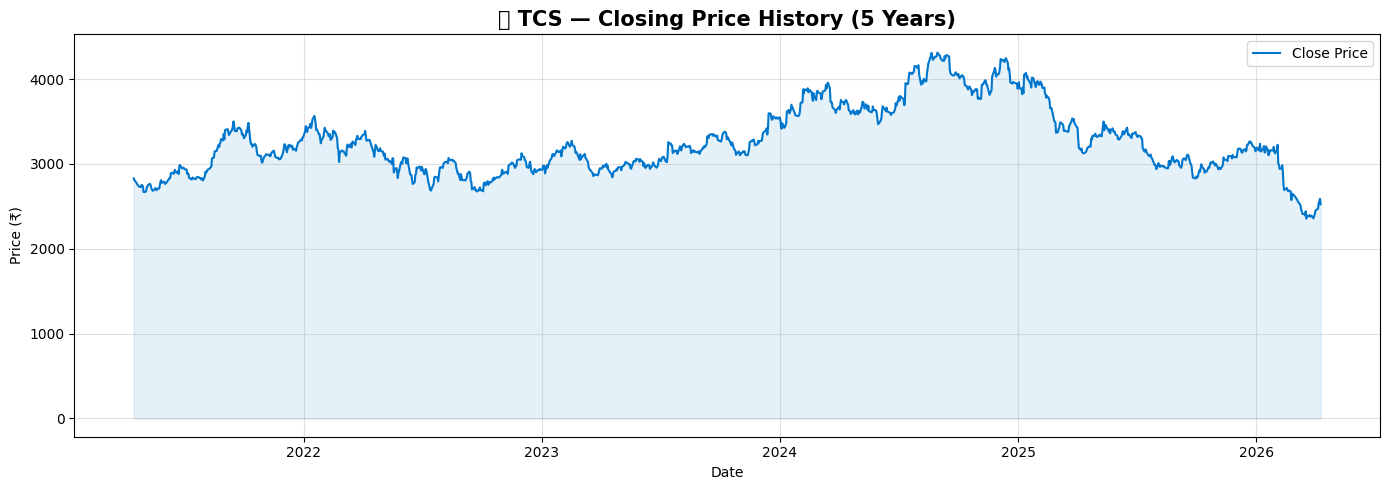

✅ Saved: TCS_closing_price.png


In [7]:
plt.figure(figsize=(14,5))
plt.plot(df["date"], df["close"], color="#0077cc", linewidth=1.5, label="Close Price")
plt.fill_between(df["date"], df["close"], alpha=0.1, color="#0077cc")

plt.title("📈 TCS — Closing Price History (5 Years)", fontsize=15, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("data/TCS_closing_price.png", dpi=150)
plt.show()
print("✅ Saved: TCS_closing_price.png")

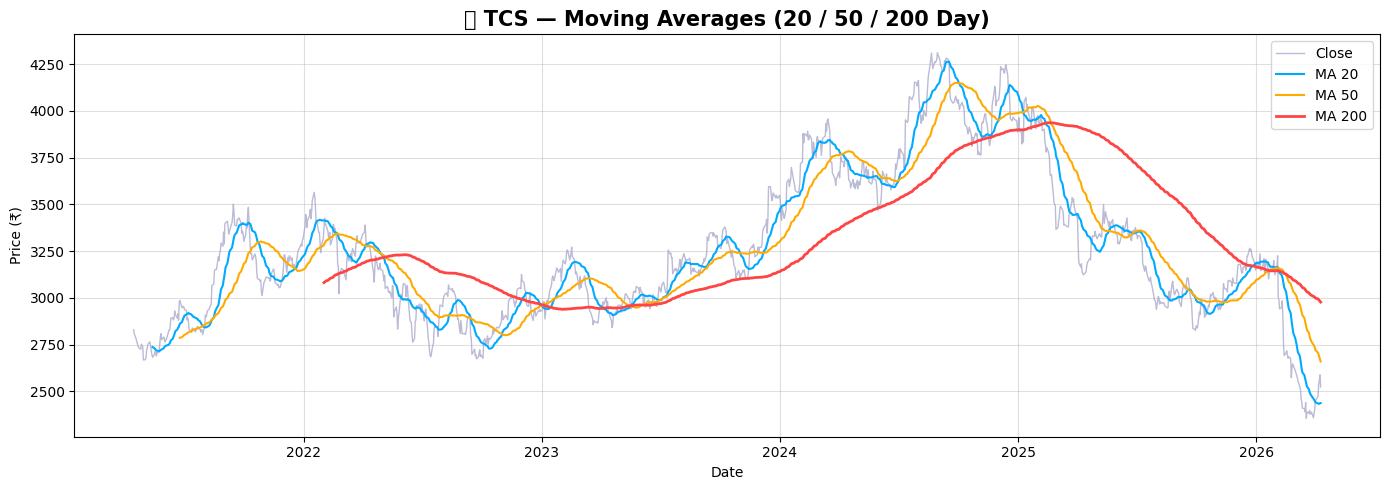

✅ Saved: TCS_moving_averages.png


In [8]:
df["MA20"]  = df["close"].rolling(20).mean()
df["MA50"]  = df["close"].rolling(50).mean()
df["MA200"] = df["close"].rolling(200).mean()

plt.figure(figsize=(14,5))
plt.plot(df["date"], df["close"], color="#aaaacc", linewidth=1,   label="Close",  alpha=0.8)
plt.plot(df["date"], df["MA20"],  color="#00aaff", linewidth=1.5, label="MA 20")
plt.plot(df["date"], df["MA50"],  color="#ffaa00", linewidth=1.5, label="MA 50")
plt.plot(df["date"], df["MA200"], color="#ff4444", linewidth=2,   label="MA 200")

plt.title("📉 TCS — Moving Averages (20 / 50 / 200 Day)", fontsize=15, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("data/TCS_moving_averages.png", dpi=150)
plt.show()
print("✅ Saved: TCS_moving_averages.png")

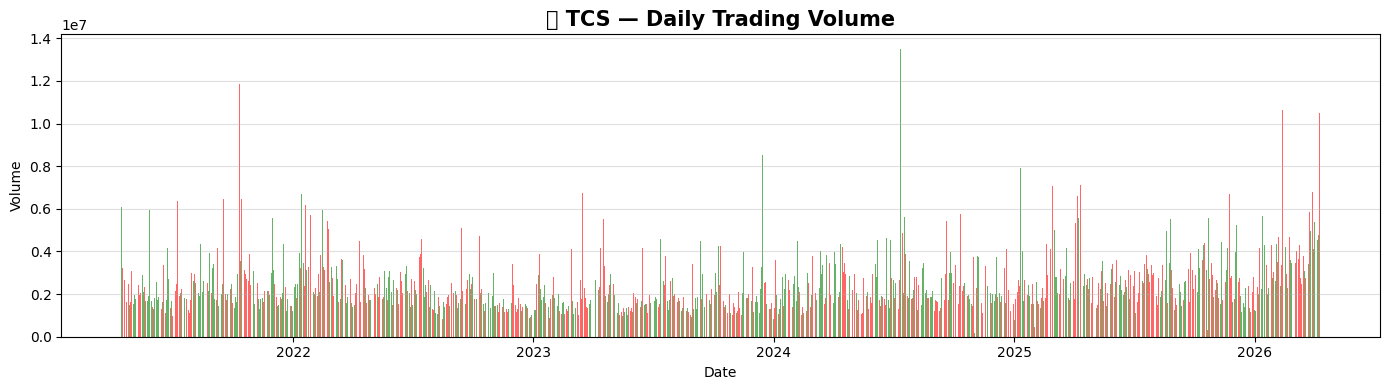

✅ Saved: TCS_volume.png


In [9]:
colors = ["green" if r >= 0 else "red" for r in df["daily_return"]]

plt.figure(figsize=(14,4))
plt.bar(df["date"], df["volume"], color=colors, alpha=0.6, width=1)
plt.title("📦 TCS — Daily Trading Volume", fontsize=15, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True, axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("data/TCS_volume.png", dpi=150)
plt.show()
print("✅ Saved: TCS_volume.png")

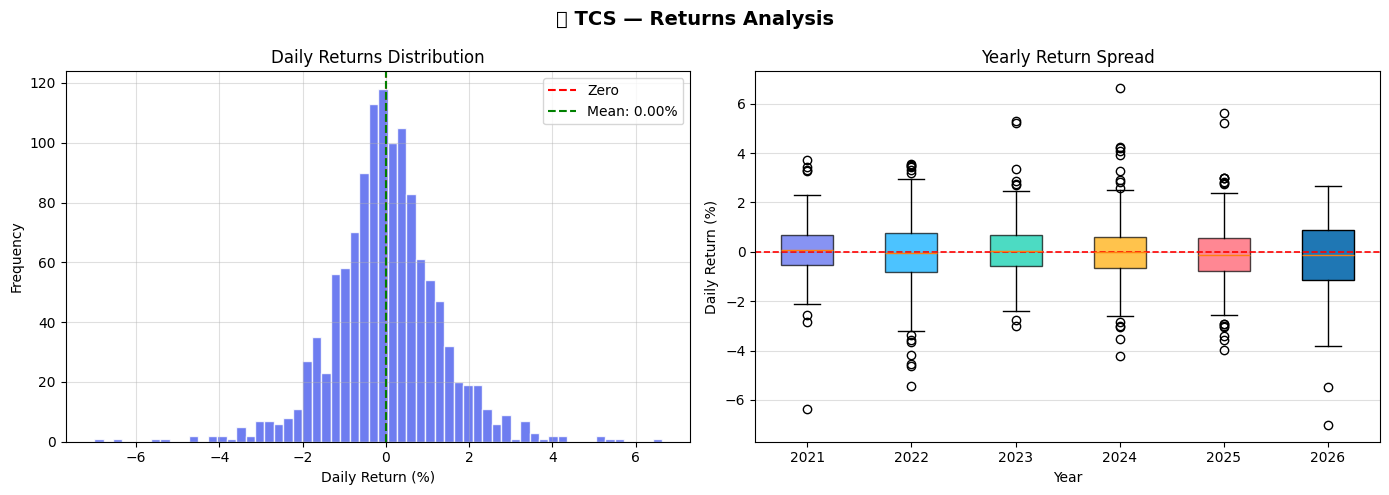

✅ Saved: TCS_returns.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df["daily_return"].dropna(), bins=60,
             color="#5566ee", edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="red",   linestyle="--", linewidth=1.5, label="Zero")
axes[0].axvline(df["daily_return"].mean(), color="green",
                linestyle="--", linewidth=1.5,
                label=f"Mean: {df['daily_return'].mean():.2f}%")
axes[0].set_title("Daily Returns Distribution")
axes[0].set_xlabel("Daily Return (%)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Yearly boxplot
df["year"] = df["date"].dt.year
years = sorted(df["year"].unique())
data_list = [df[df["year"]==y]["daily_return"].dropna().values for y in years]

bp = axes[1].boxplot(data_list, labels=years, patch_artist=True)
box_colors = ["#5566ee","#00aaff","#00ccaa","#ffaa00","#ff5566"]
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.2)
axes[1].set_title("Yearly Return Spread")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Daily Return (%)")
axes[1].grid(True, axis="y", alpha=0.4)

plt.suptitle("📊 TCS — Returns Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("data/TCS_returns.png", dpi=150)
plt.show()
print("✅ Saved: TCS_returns.png")

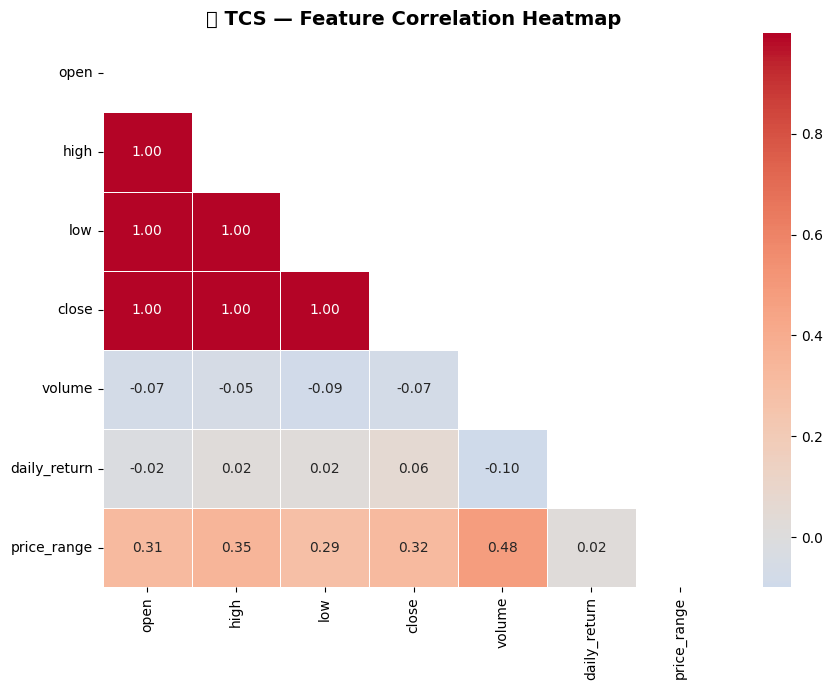

✅ Saved: TCS_correlation.png


In [11]:
cols = ["open","high","low","close","volume","daily_return","price_range"]

plt.figure(figsize=(9, 7))
corr = df[cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5)

plt.title("🔥 TCS — Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("data/TCS_correlation.png", dpi=150)
plt.show()
print("✅ Saved: TCS_correlation.png")

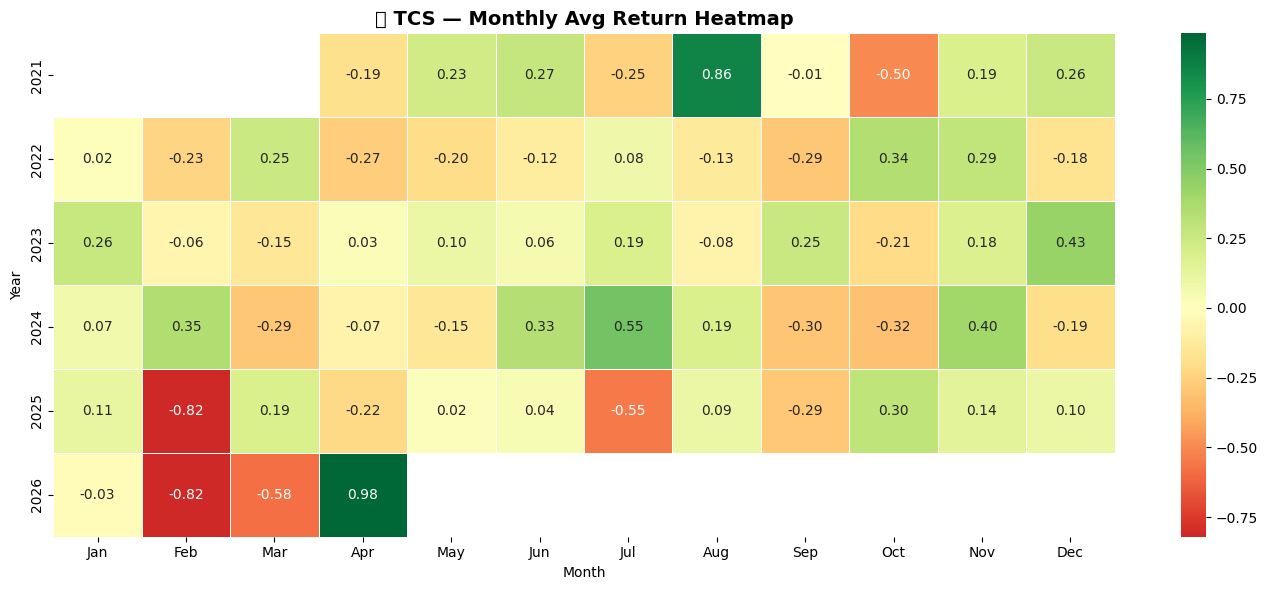

✅ Saved: TCS_monthly_heatmap.png


In [12]:
df["month"] = df["date"].dt.month
monthly = df.groupby(["year","month"])["daily_return"].mean().unstack()
monthly.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                   "Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(14, 6))
sns.heatmap(monthly, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, linewidths=0.5)
plt.title("📅 TCS — Monthly Avg Return Heatmap", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.savefig("data/TCS_monthly_heatmap.png", dpi=150)
plt.show()
print("✅ Saved: TCS_monthly_heatmap.png")

In [13]:
import pandas as pd
import sys
sys.path.append("src")

from features import build_all_features, plot_rsi, plot_macd, plot_bollinger, plot_feature_importance, save_featured_data

# Load TCS data
df = pd.read_csv("data/TCS_stock_data.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

# Build all features in one shot
df = build_all_features(df)


🔧 Building all features...

✅ RSI(14) added
✅ MACD(12,26,9) added
✅ Bollinger Bands(20, 2) added
✅ Extra indicators added (MA, EMA, ATR, Volume, Momentum, Lags)
✅ Target variable added (predicting 1 day ahead)

📊 Rows before cleaning : 1234
📊 Rows after  cleaning : 1034
📊 Total features built : 39

✅ All features ready!

Feature columns:
['date', 'close', 'high', 'low', 'open', 'volume', 'ticker', 'daily_return', 'price_range', 'avg_price', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'BB_Pct', 'MA7', 'MA20', 'MA50', 'MA200', 'EMA12', 'EMA26', 'Price_MA20_ratio', 'Price_MA50_ratio', 'ATR', 'Volume_MA20', 'Volume_ratio', 'Momentum_10', 'ROC_10', 'Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Close_lag_5', 'Close_lag_10', 'Target', 'Target_Return']


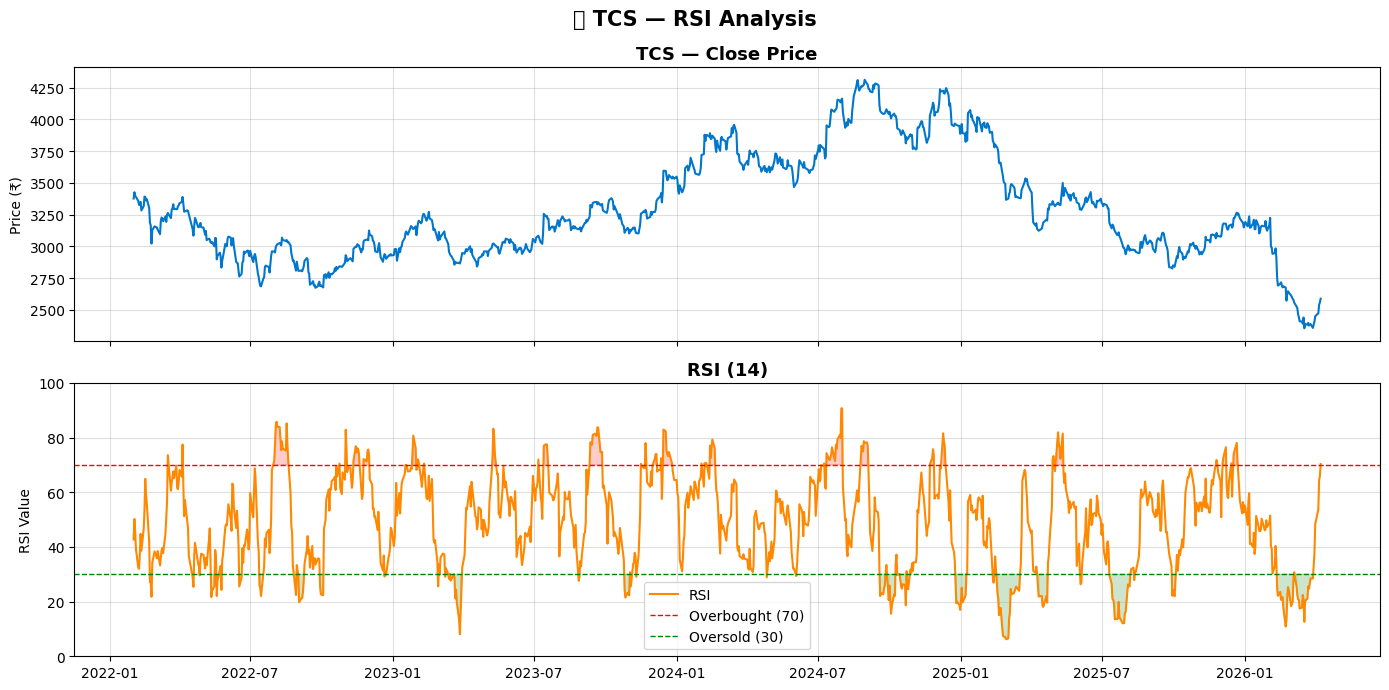

✅ Saved: data/TCS_RSI.png


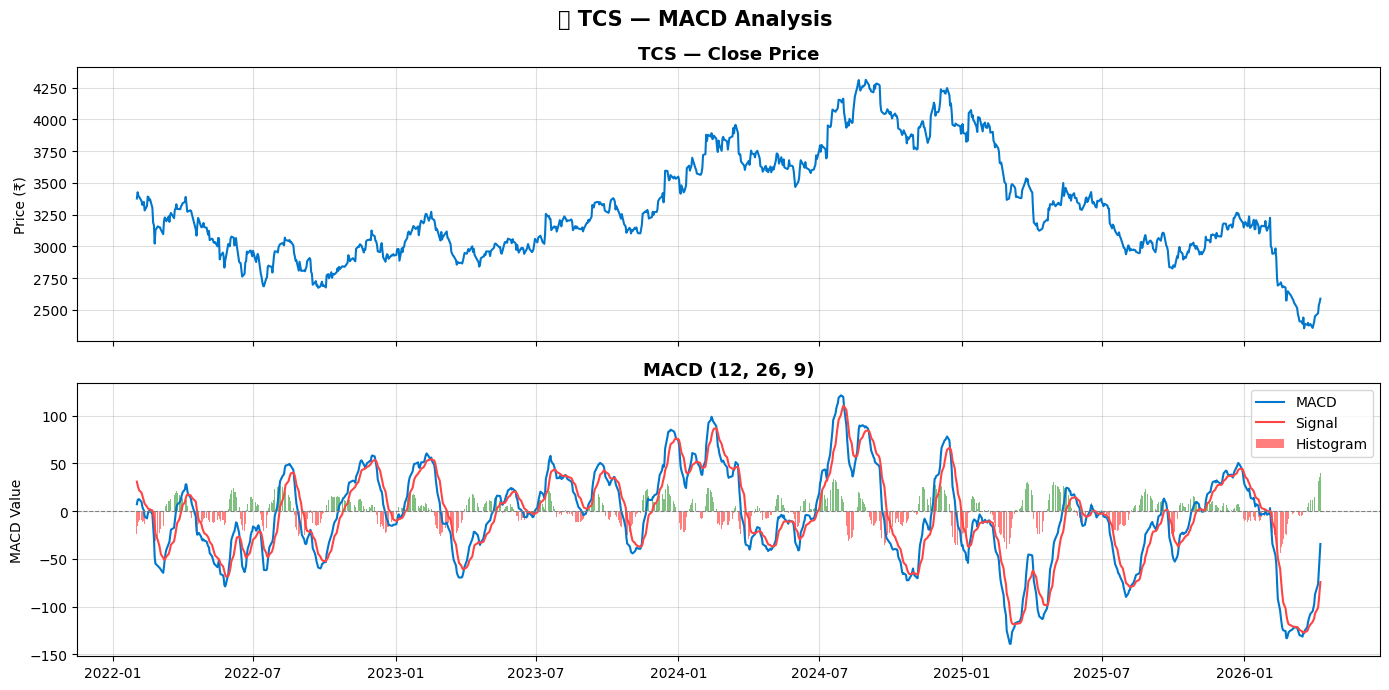

✅ Saved: data/TCS_MACD.png


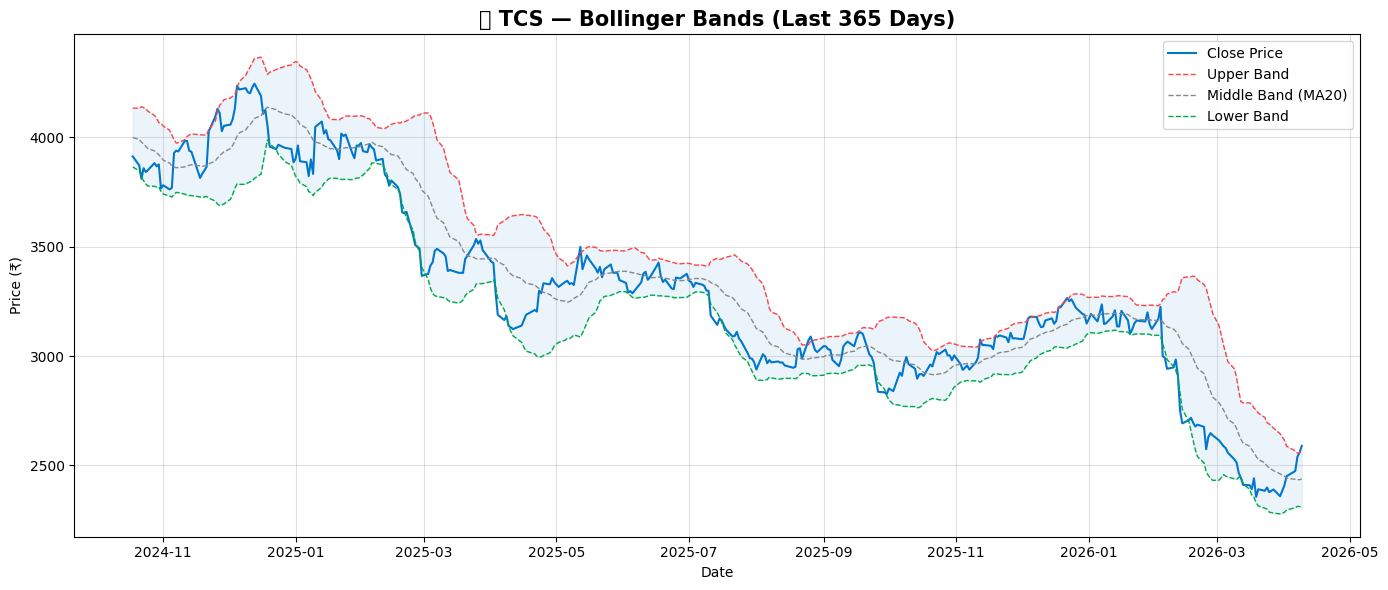

✅ Saved: data/TCS_Bollinger.png


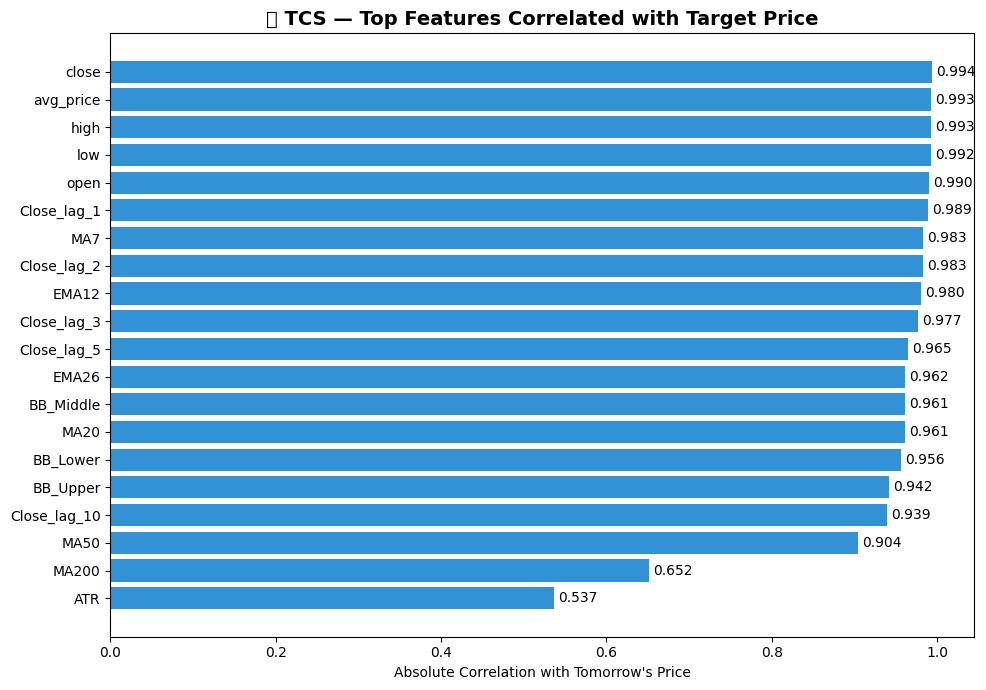

✅ Saved: data/TCS_feature_importance.png


In [14]:
plot_rsi(df, "TCS")
plot_macd(df, "TCS")
plot_bollinger(df, "TCS")
plot_feature_importance(df, "TCS")

In [15]:
save_featured_data(df, "TCS")

💾 Featured data saved: data/TCS_featured.csv
   Rows: 1034 | Columns: 39


'data/TCS_featured.csv'

In [16]:
import pandas as pd
import sys
sys.path.append("src")

from model import run_baseline

# Load the featured data from Phase 3
df = pd.read_csv("data/TCS_featured.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"✅ Loaded: {len(df)} rows")

✅ Loaded: 1034 rows



🚀 Phase 4 — ML Baseline for TCS
✅ Data prepared!
   Train : 827 rows
   Test  : 207  rows
   Features : 27

🚀 Training all baseline models...

⏳ Training: Linear Regression...

📊 Linear Regression Results:
   RMSE : ₹44.53   (lower is better)
   MAE  : ₹32.31   (lower is better)
   R²   : 0.9696    (closer to 1 is better)
⏳ Training: Ridge Regression...

📊 Ridge Regression Results:
   RMSE : ₹43.44   (lower is better)
   MAE  : ₹31.45   (lower is better)
   R²   : 0.9710    (closer to 1 is better)
⏳ Training: Lasso Regression...

📊 Lasso Regression Results:
   RMSE : ₹49.58   (lower is better)
   MAE  : ₹36.90   (lower is better)
   R²   : 0.9623    (closer to 1 is better)
⏳ Training: Random Forest...

📊 Random Forest Results:
   RMSE : ₹112.07   (lower is better)
   MAE  : ₹66.03   (lower is better)
   R²   : 0.8073    (closer to 1 is better)
⏳ Training: Gradient Boosting...

📊 Gradient Boosting Results:
   RMSE : ₹112.82   (lower is better)
   MAE  : ₹67.25   (lower is better)
   R²

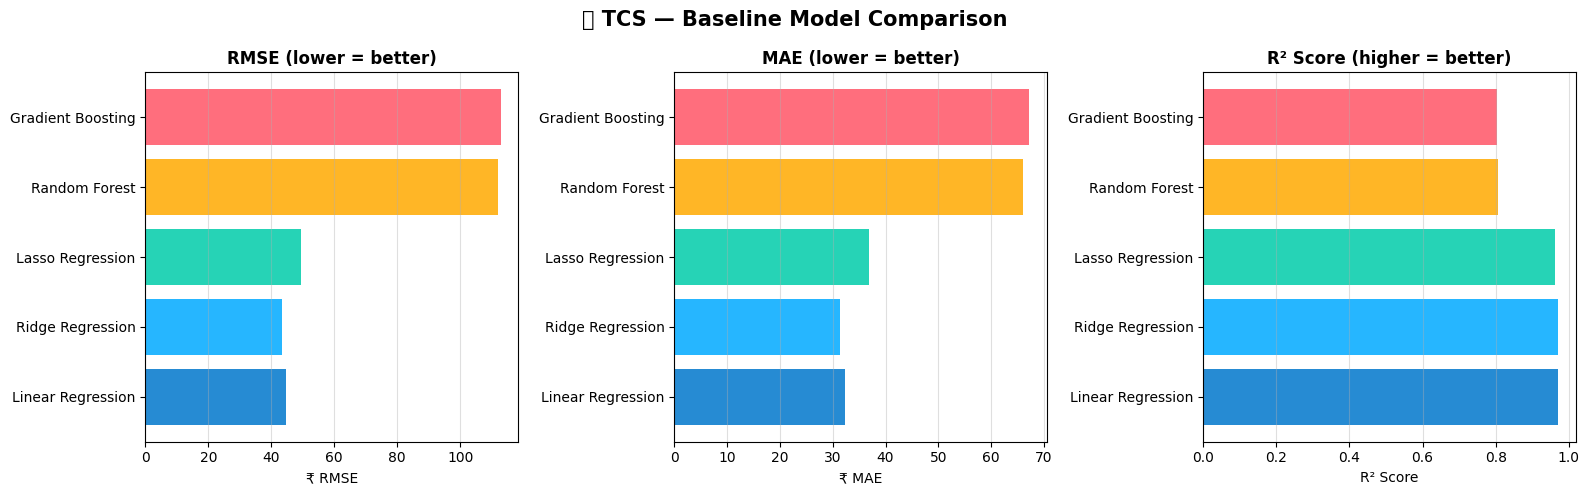

✅ Saved: data/TCS_model_comparison.png

📋 Summary Table:
                       RMSE      MAE      R2
model                                       
Linear Regression   44.5290  32.3052  0.9696
Ridge Regression    43.4434  31.4478  0.9710
Lasso Regression    49.5753  36.9036  0.9623
Random Forest      112.0695  66.0255  0.8073
Gradient Boosting  112.8196  67.2488  0.8047

🏆 Best Model: Ridge Regression
   RMSE : ₹43.44
   R²   : 0.9710


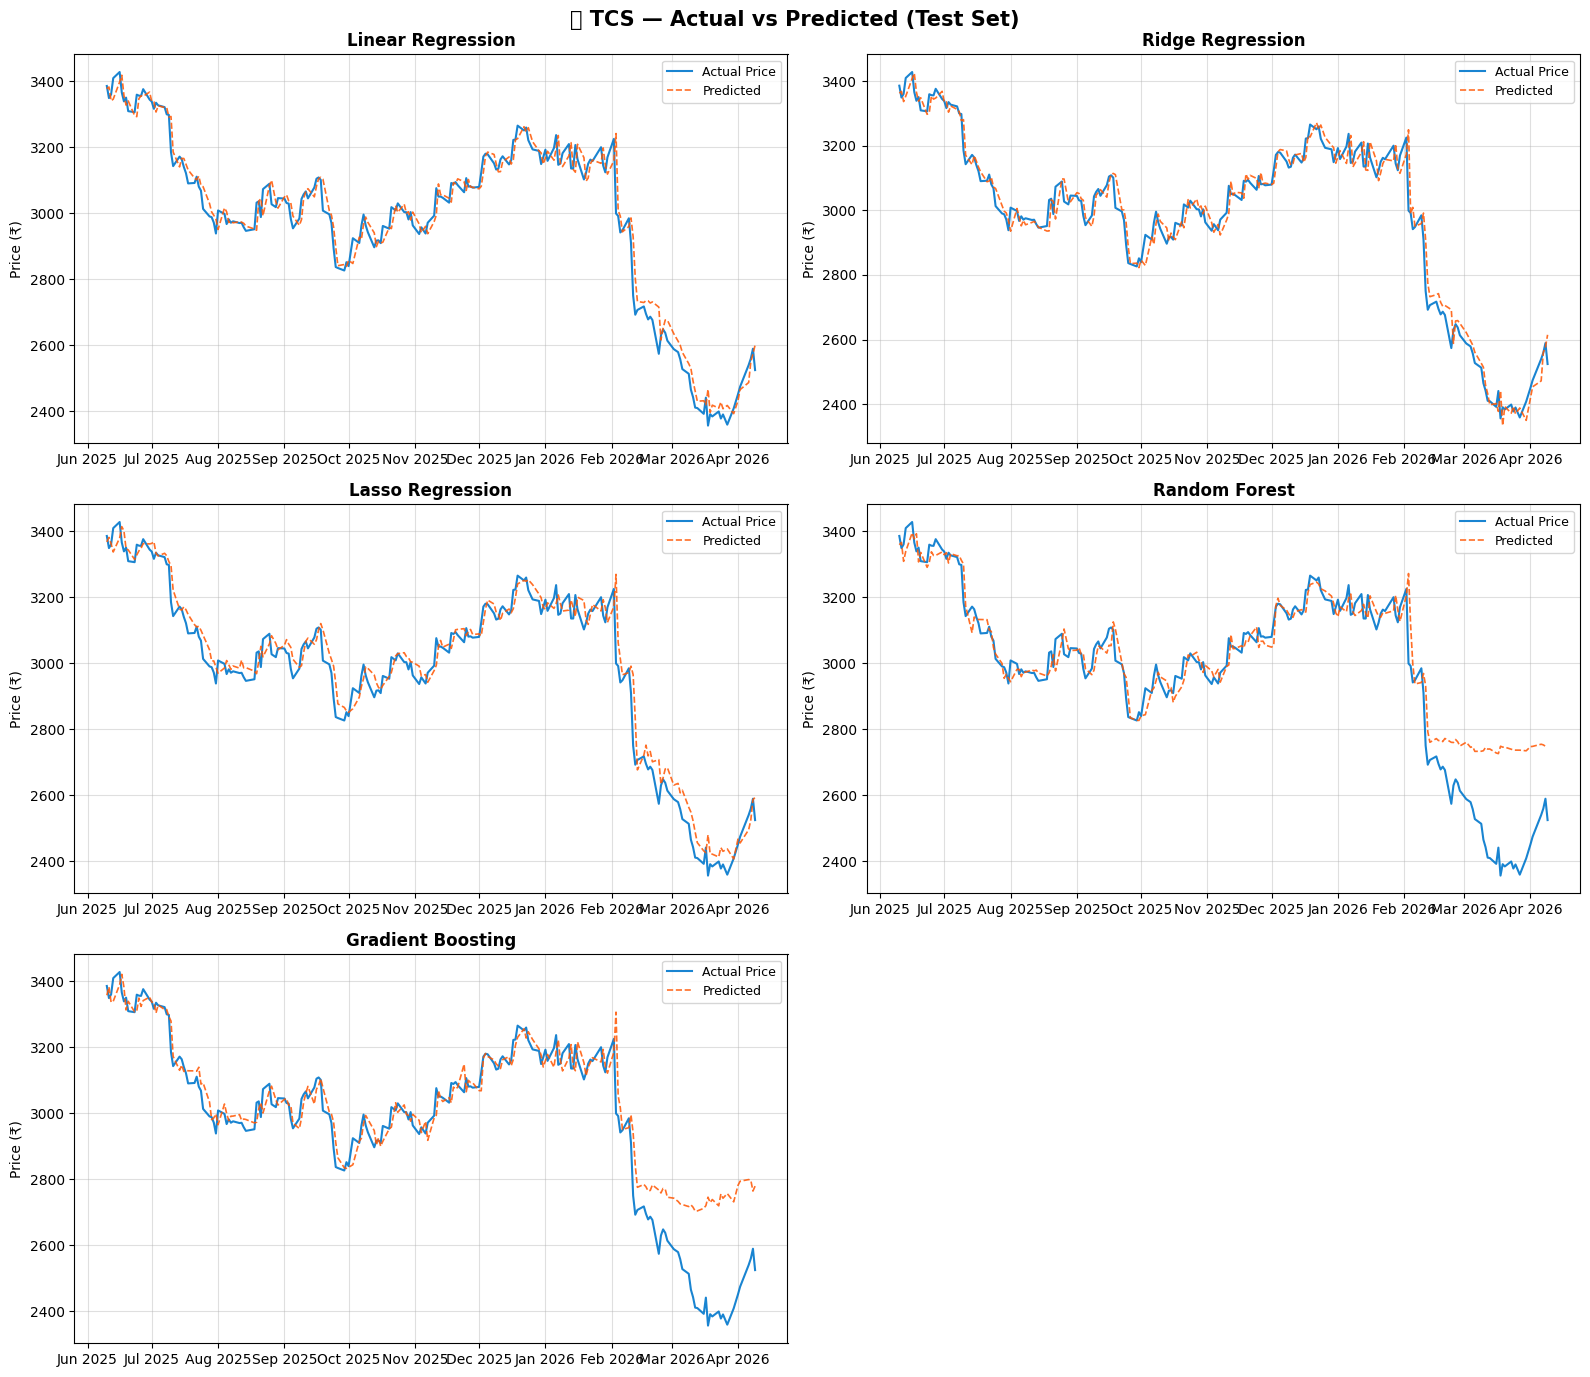

✅ Saved: data/TCS_predictions.png


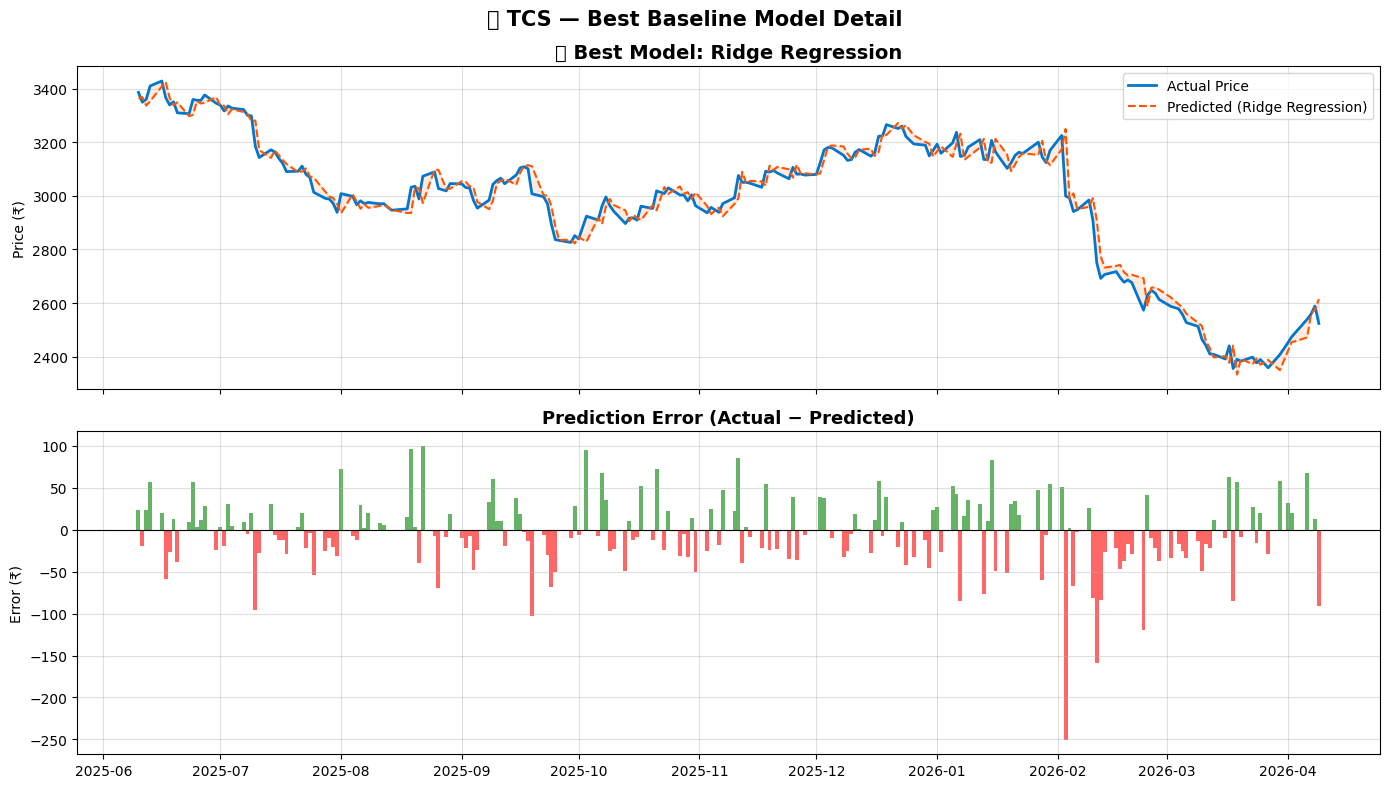

✅ Saved: data/TCS_best_model.png

💾 Best model saved: models/TCS_baseline_model.pkl

🎉 Phase 4 Complete!
🏆 Best Baseline: Ridge Regression
📌 This RMSE is our benchmark — LSTM must beat this!



In [17]:
# Trains 5 models + compares + saves best one
results_df, predictions, best_name = run_baseline(df, ticker="TCS")

In [18]:
import sys
print(sys.version)

3.11.7 (tags/v3.11.7:fa7a6f2, Dec  4 2023, 19:24:49) [MSC v.1937 64 bit (AMD64)]



🧠 Phase 5 — LSTM for TCS
🎯 Target to beat → RMSE: ₹43.44 | R²: 0.9710
✅ LSTM data ready!
   Train sequences : (767, 60, 28)
   Test  sequences : (147, 60, 28)
   Input shape     : (samples=767, timesteps=60, features=28)

📋 Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 128)             │          80,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 60, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 132,673 (518.25 KB)

 Trainable params: 132,289 (516.75 KB)

 Non-trainable params: 384 (1.50 KB)


🚀 Training LSTM for TCS...
   Max Epochs  : 100
   Batch Size  : 32
   Early Stop  : patience=15

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.5836 - mae: 0.5747 - val_loss: 0.0821 - val_mae: 0.2616 - learning_rate: 0.0010
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.3182 - mae: 0.4473 - val_loss: 0.0748 - val_mae: 0.2510 - learning_rate: 0.0010
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.2558 - mae: 0.4004 - val_loss: 0.0516 - val_mae: 0.1999 - learning_rate: 0.0010
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.1902 - mae: 0.3425 - val_loss: 0.0425 - val_mae: 0.1863 - learning_rate: 0.0010
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.1628 - mae: 0.3157 - val_loss: 0.0190 - val_mae: 0.1241 - learning_rate: 0.0010
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.1450 - mae: 0.3059 - val_loss: 0.0097 - val_mae: 0.0817 - learning_rate: 0.0010
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/st

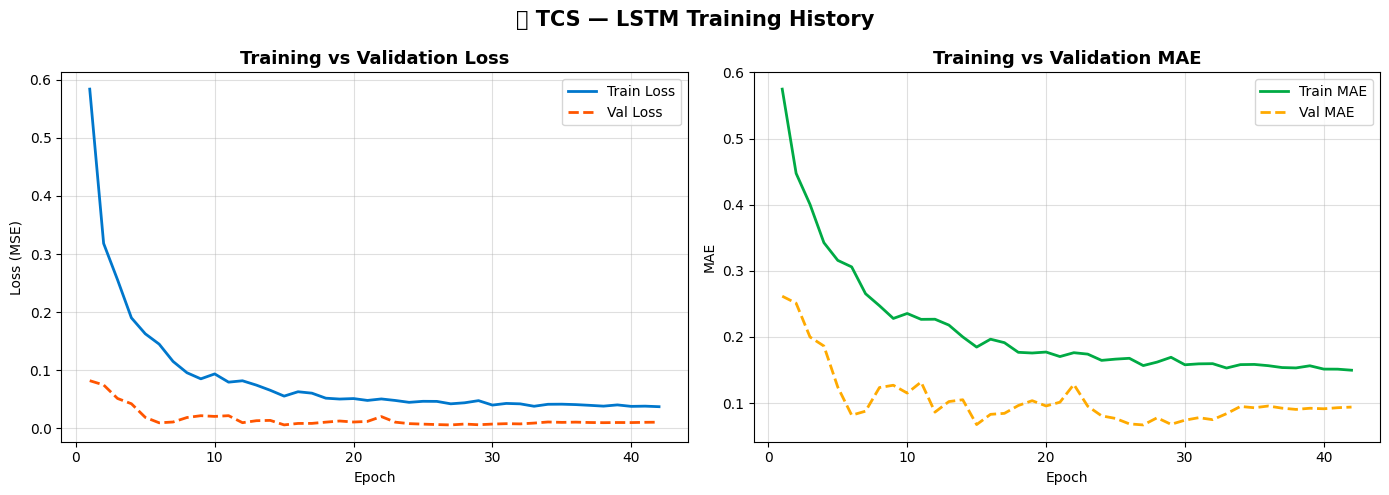

✅ Saved: data/TCS_lstm_training.png
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

        🧠 LSTM RESULTS
  RMSE : ₹151.91
  MAE  : ₹130.87
  R²   : 0.6548

  📊 vs Baseline (Ridge Regression):
  Baseline RMSE : ₹43.44   →  LSTM: ₹151.91  ❌ NOT YET
  Baseline R²   :  0.9710  →  LSTM:  0.6548  ❌ NOT YET


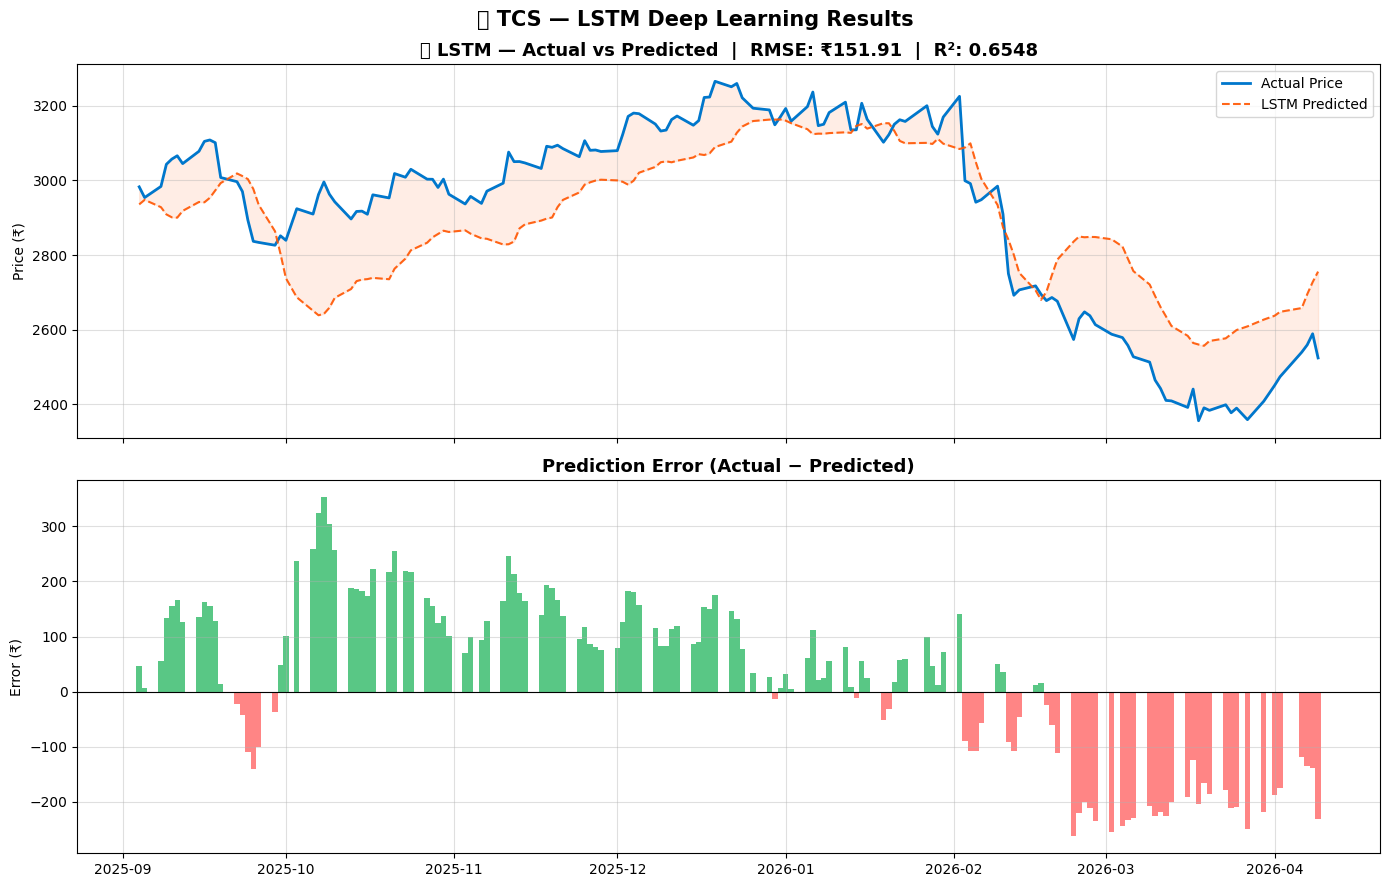

✅ Saved: data/TCS_lstm_predictions.png

📅 TCS — Next 7 Days Forecast:
  Last Close : ₹2589.00
      Date  Predicted_Price   Day   Change_₹  Change_% Signal
2026-04-10      2767.649902 Day 1 178.649994      6.90  🟢 BUY
2026-04-13      2770.969971 Day 2 181.970001      7.03  🟢 BUY
2026-04-14      2765.989990 Day 3 176.990005      6.84  🟢 BUY
2026-04-15      2759.100098 Day 4 170.100006      6.57  🟢 BUY
2026-04-16      2757.239990 Day 5 168.240005      6.50  🟢 BUY
2026-04-17      2759.719971 Day 6 170.720001      6.59  🟢 BUY
2026-04-20      2760.600098 Day 7 171.600006      6.63  🟢 BUY


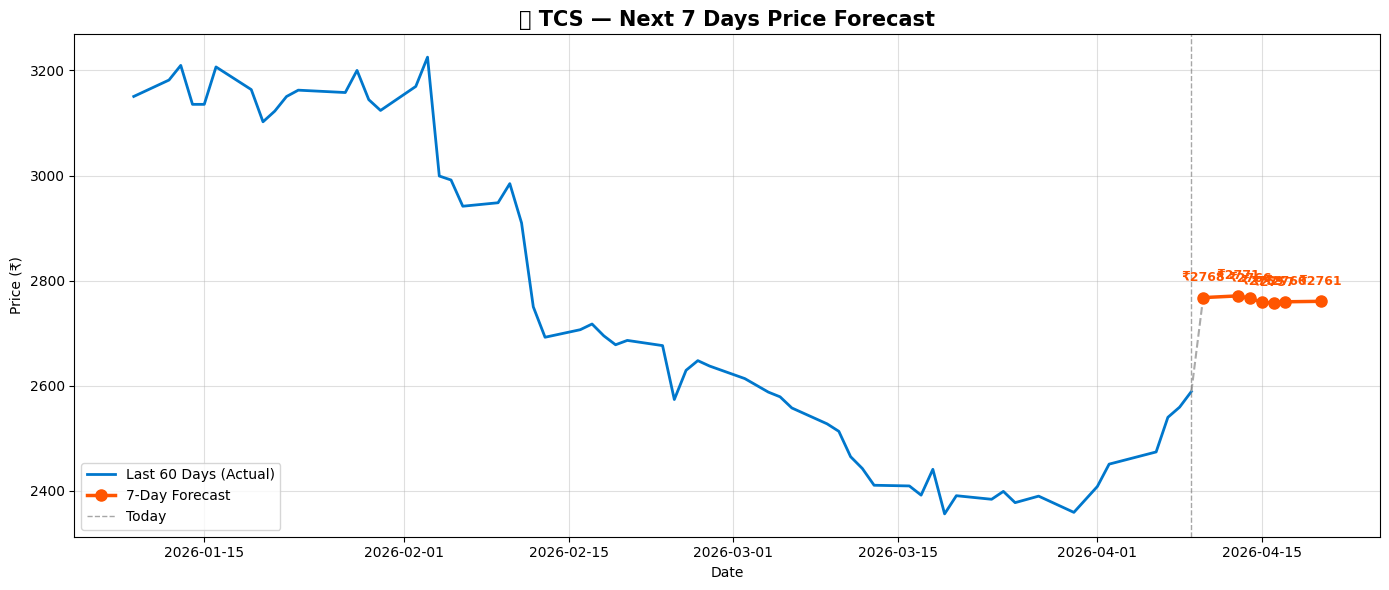

✅ Saved: data/TCS_7day_forecast.png

💾 LSTM saved: models/TCS_lstm.keras
💾 Scalers saved: models/TCS_lstm_scalers.pkl

🎉 Phase 5 Complete!


In [19]:
import pandas as pd
import sys
sys.path.append("src")

from lstm import run_lstm

# Load featured data
df = pd.read_csv("data/TCS_featured.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

# Run everything!
model, history, metrics, forecast = run_lstm(df, ticker="TCS")

In [20]:
print(forecast)

        Date  Predicted_Price    Day    Change_₹  Change_% Signal
0 2026-04-10      2767.649902  Day 1  178.649994      6.90  🟢 BUY
1 2026-04-13      2770.969971  Day 2  181.970001      7.03  🟢 BUY
2 2026-04-14      2765.989990  Day 3  176.990005      6.84  🟢 BUY
3 2026-04-15      2759.100098  Day 4  170.100006      6.57  🟢 BUY
4 2026-04-16      2757.239990  Day 5  168.240005      6.50  🟢 BUY
5 2026-04-17      2759.719971  Day 6  170.720001      6.59  🟢 BUY
6 2026-04-20      2760.600098  Day 7  171.600006      6.63  🟢 BUY
